<a href="https://colab.research.google.com/github/vitor-thompson/Python-para-financas-investimento-e-analise-de-dados./blob/main/Monte_Carlo_Previs%C3%A3o_dos_pre%C3%A7os_de_a%C3%A7%C3%B5es.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Instala a biblioteca yfinance silenciosamente.
!pip install -q yfinance
# Importa a biblioteca numpy para operações numéricas.
import numpy as np
# Importa a biblioteca pandas para manipulação de dados.
import pandas as pd
# Importa a biblioteca yfinance para buscar dados financeiros.
import yfinance as yf
# Importa a biblioteca matplotlib.pyplot para visualização de gráficos.
import matplotlib.pyplot as plt
# Importa a função norm da scipy.stats para manipulação de distribuição normal.
from scipy.stats import norm
# Configura o matplotlib para exibir gráficos inline no notebook.
%matplotlib inline

In [ ]:
# Define o ticker (símbolo) da ação que será analisada.
ticker =  ['ITUB4.SA']
# Cria um DataFrame vazio para armazenar os dados do preço de fechamento.
data = pd.DataFrame()
# Baixa os dados históricos do preço de fechamento da ação 'PG' desde 1º de janeiro de 2007.
data[ticker] = yf.download(ticker, start='2020-1-1')['Close']

/tmp/ipython-input-1206842715.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data[ticker] = yf.download(ticker, start='2020-1-1')['Close']
[*********************100%***********************]  1 of 1 completed


In [ ]:
# Calcula os retornos logarítmicos diários.
# A fórmula é log(1 + variação percentual diária).
# Retornos logarítmicos são preferidos para modelagem financeira devido às suas propriedades estatísticas.
log_returns = np.log(1 + data.pct_change())

In [ ]:
# Exibe as primeiras linhas dos retornos logarítmicos calculados.
log_returns.head()

,ITUB4.SA
Date,
2020-01-02,NaN
2020-01-03,-0.010574
2020-01-06,-0.014994
2020-01-07,-0.023472
2020-01-08,-0.016429


In [ ]:
# Exibe as últimas linhas dos retornos logarítmicos calculados.
log_returns.tail()

,ITUB4.SA
Date,
2025-12-08,0.004836
2025-12-09,-0.002173
2025-12-10,0.007839
2025-12-11,-0.000761
2025-12-12,0.008842


<Axes: xlabel='Date'>

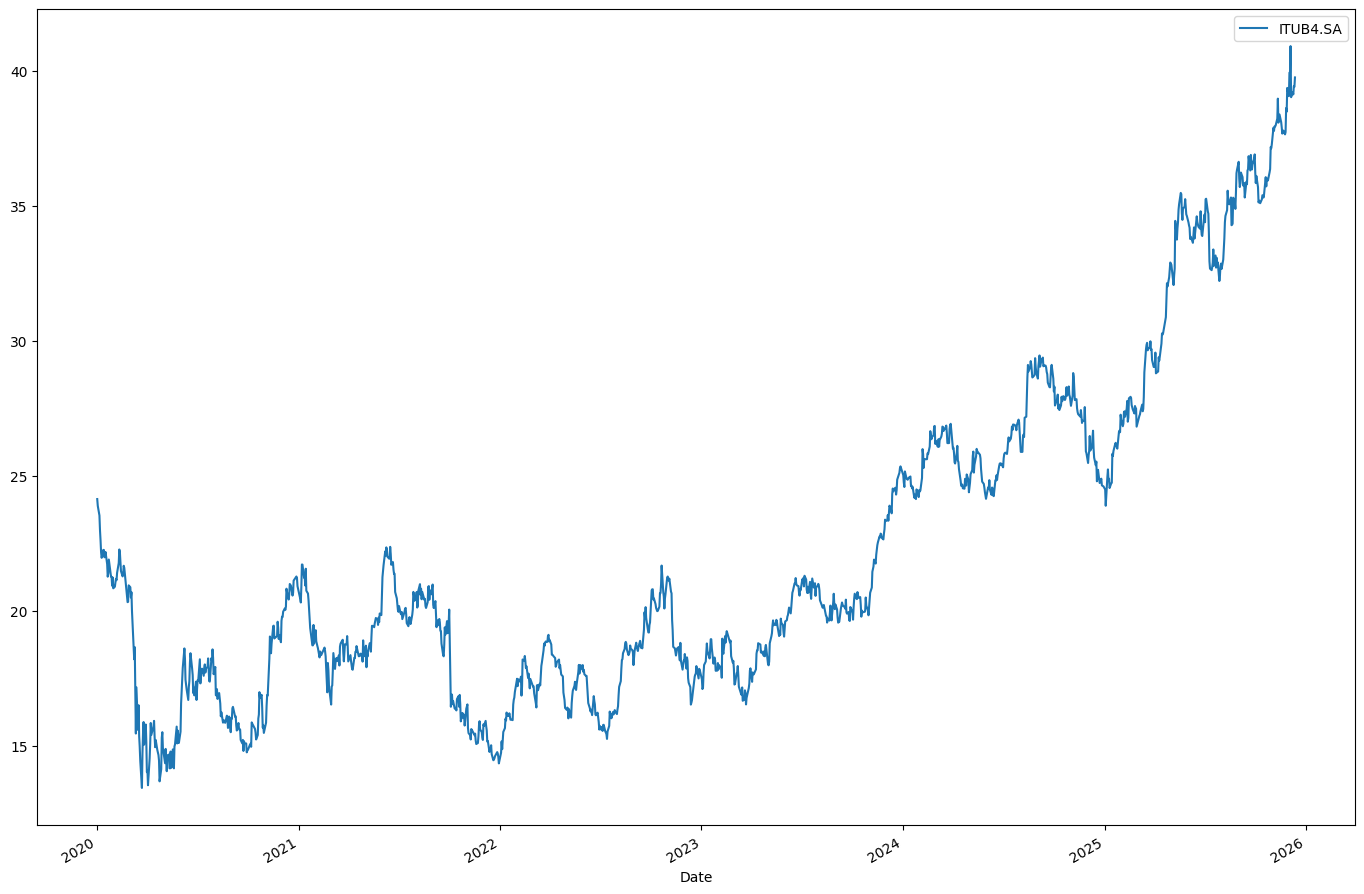

In [ ]:
# Plota o histórico dos preços de fechamento da ação 'PG'.
# O gráfico ajuda a visualizar a tendência geral do preço ao longo do tempo.
data.plot(figsize=(17, 12))

<Axes: xlabel='Date'>

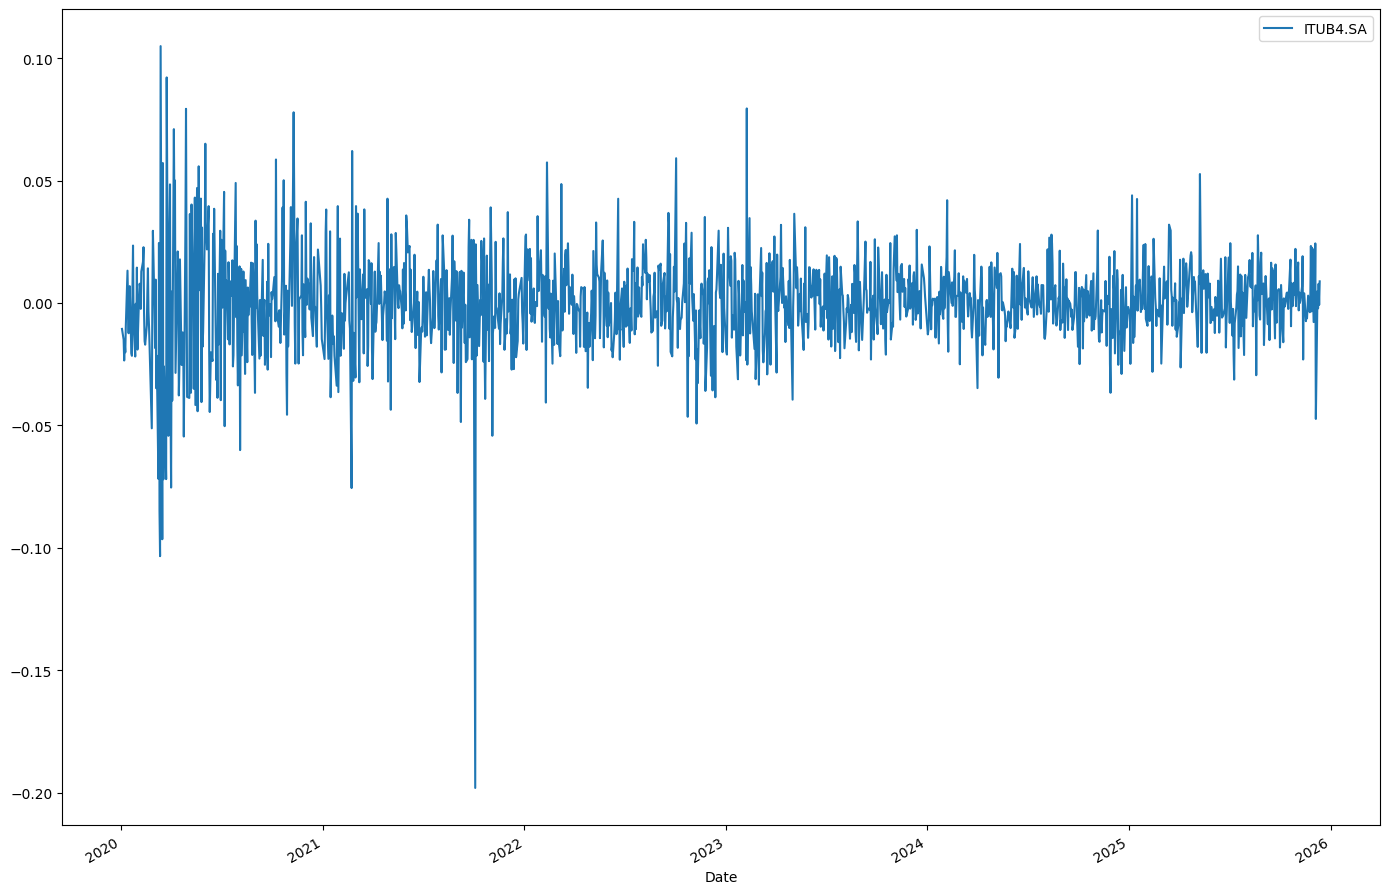

In [ ]:
# Plota o histórico dos retornos logarítmicos diários.
# Este gráfico visualiza a volatilidade e as tendências dos retornos ao longo do tempo.
log_returns.plot(figsize=(17, 12))

In [ ]:
# Calcula a média dos retornos logarítmicos diários.
# Este valor representa o retorno diário médio esperado da ação.
media = log_returns.mean()
media

,0
ITUB4.SA,0.000337


In [ ]:
# Calcula a variância dos retornos logarítmicos diários.
# A variância é uma medida da dispersão dos retornos.
variacia = log_returns.var()
variacia

,0
ITUB4.SA,0.000373


In [ ]:
# Calcula o 'drift' (deriva) do processo estocástico dos preços.
# O drift representa a tendência direcional dos retornos logarítmicos.
# É um componente chave no modelo de Black-Scholes para simulação de preços de ativos.
drift = media - (0.5 * variacia)
drift

,0
ITUB4.SA,0.00015


In [ ]:
# Calcula o desvio padrão dos retornos logarítmicos diários.
# O desvio padrão é a volatilidade diária do ativo.
desvio_padrao = log_returns.std()
desvio_padrao

,0
ITUB4.SA,0.019312


In [ ]:
# Extrai os valores do objeto 'drift' como um array NumPy.
# Isso é necessário para realizar operações matemáticas com arrays.
drift.values

array([0.00015005])

In [ ]:
# Extrai os valores do objeto 'desvio_padrao' como um array NumPy.
# Essencial para cálculos que exigem arrays numéricos.
desvio_padrao.values

array([0.01931226])

In [ ]:
# Gera um array de 10x2 com números aleatórios uniformemente distribuídos entre 0 e 1.
# Isso simula entradas aleatórias para funções de distribuição.
x = np.random.rand(10, 2)
x

array([[0.06972834, 0.07822995],
       [0.83965296, 0.2193933 ],
       [0.60529524, 0.11490472],
       [0.33574304, 0.97619029],
       [0.18538035, 0.69508312],
       [0.7298274 , 0.16286833],
       [0.31269328, 0.92043068],
       [0.84842305, 0.37634082],
       [0.41714277, 0.80969458],
       [0.87187665, 0.89566824]])

In [ ]:
# Aplica a função de percentil inverso (ppf) da distribuição normal padrão aos valores do array 'x'.
# Isso transforma os números aleatórios uniformes em números com uma distribuição normal.
norm.ppf(x)

array([[-1.47781733, -1.41707876],
       [ 0.99303258, -0.77424385],
       [ 0.26707745, -1.20084989],
       [-0.42410933,  1.98074914],
       [-0.89504936,  0.51031076],
       [ 0.61229106, -0.98273747],
       [-0.48823054,  1.40797445],
       [ 1.02969353, -0.3151054 ],
       [-0.20920843,  0.87677137],
       [ 1.13530701,  1.2572489 ]])

In [ ]:
# Gera diretamente um array de 10x2 de números aleatórios com uma distribuição normal padrão (Z-scores).
# Isso é uma forma eficiente de obter valores aleatórios normalmente distribuídos.
z = norm.ppf(np.random.rand(10, 2))
z

array([[-0.46625338, -1.09221433],
       [ 0.42241156,  0.2239794 ],
       [-0.5848796 ,  0.63264163],
       [-0.13040033,  0.3429771 ],
       [ 0.4395208 ,  0.17780784],
       [-1.14221996,  0.13898315],
       [-0.31239851,  0.61470835],
       [-0.88139497, -0.31993213],
       [-1.21160351,  0.86487221],
       [-1.12086034, -0.2915618 ]])

In [ ]:
# Define o número de intervalos de tempo para a simulação (dias).
t_intervalos = 1000
# Define o número de interações (caminhos de preço simulados).
interacoes = 1000

In [ ]:
# Calcula os retornos diários simulados usando a fórmula de um Movimento Browniano Geométrico.
# Esta fórmula incorpora o drift (tendência) e a volatilidade (desvio_padrao) da ação,
# juntamente com um componente aleatório de uma distribuição normal.
# np.exp é usado para converter os retornos logarítmicos em retornos simples (fator multiplicador).
retorno_acumulado = np.exp(drift.values + desvio_padrao.values * norm.ppf(np.random.rand(t_intervalos, interacoes)))
retorno_acumulado

array([[0.98270674, 1.00725919, 0.98148076, ..., 1.02535462, 0.98405222,
        1.01315745],
       [0.95535536, 1.00447475, 1.06234097, ..., 0.98971466, 0.99225958,
        0.98006499],
       [1.00417709, 1.01216918, 0.96105264, ..., 0.98337229, 0.99869091,
        1.03007563],
       ...,
       [0.99448534, 0.99769319, 1.00166033, ..., 0.98041072, 0.96775099,
        1.0035976 ],
       [0.99112082, 0.97783563, 0.9799404 , ..., 1.01113837, 0.9989655 ,
        1.00367794],
       [1.0460848 , 1.02004165, 1.02484847, ..., 1.00397951, 1.0147303 ,
        1.03797668]])

In [ ]:
# Obtém o último preço de fechamento da ação a partir do DataFrame 'data'.
# Este será o preço inicial (S0) para as simulações de Monte Carlo.
S0 = data.iloc[-1]
S0

,2025-12-12
ITUB4.SA,39.759998


In [ ]:
# Cria uma matriz de zeros com as mesmas dimensões de 'retorno_acumulado'.
# Esta matriz será usada para armazenar os preços simulados da ação ao longo do tempo.
lista_precos = np.zeros_like(retorno_acumulado)
lista_precos

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
# Define a primeira linha da matriz 'lista_precos' com o preço inicial (S0).
# Todas as simulações começam do mesmo preço atual.
lista_precos[0] = S0
lista_precos

array([[39.75999832, 39.75999832, 39.75999832, ..., 39.75999832,
        39.75999832, 39.75999832],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ]])

In [ ]:
# Loop para simular os preços futuros da ação.
# Para cada intervalo de tempo (dia), o preço é calculado multiplicando o preço do dia anterior
# pelo retorno acumulado simulado para aquele dia e interação.
for t in range(1, t_intervalos):
    lista_precos[t] = lista_precos[t - 1] * retorno_acumulado[t]

In [ ]:
# Exibe a matriz completa de preços simulados.
# Cada coluna representa uma simulação de caminho de preço para a ação.
lista_precos

array([[39.75999832, 39.75999832, 39.75999832, ..., 39.75999832,
        39.75999832, 39.75999832],
       [37.98492739, 39.93791457, 42.23867505, ..., 39.35105331,
        39.45223914, 38.96738253],
       [38.14359391, 40.42392643, 40.59359031, ..., 38.69673546,
        39.40059263, 40.13935116],
       ...,
       [52.95825388, 61.11264081, 53.00600241, ..., 64.9594751 ,
        39.15793276, 23.55984214],
       [52.48802826, 59.75811776, 51.94272298, ..., 65.68301749,
        39.1174238 , 23.6464938 ],
       [54.90692874, 60.95576883, 53.23341993, ..., 65.9444036 ,
        39.69363502, 24.54450917]])

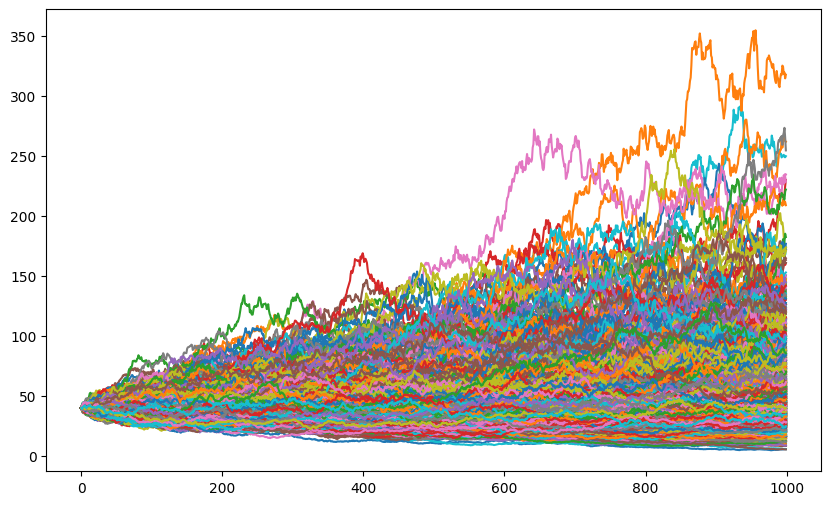

In [ ]:
# Cria uma nova figura para o gráfico com um tamanho específico.
plt.figure(figsize=(10, 6))
# Plota todos os caminhos de preço simulados.
# Cada linha no gráfico representa uma das 'interacoes' simulações.
plt.plot(lista_precos)
# Oculta o eixo x para que o gráfico fique mais limpo (geralmente representa o número do passo de tempo).
plt.show()

# Hiscorico de preços simulados

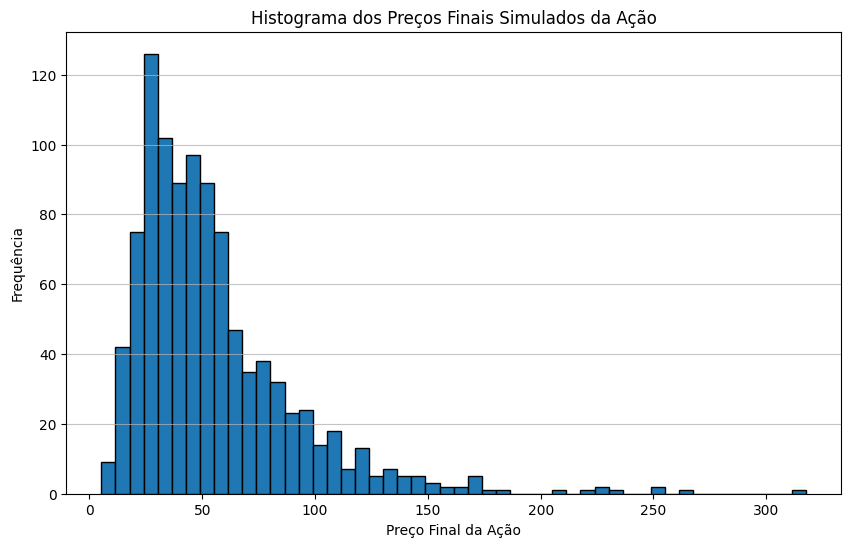

In [ ]:
# Cria uma nova figura para o histograma.
plt.figure(figsize=(10, 6))

# Plota o histograma dos preços finais simulados.
# Usamos lista_precos[-1] para obter a última linha, que corresponde aos preços finais de cada simulação.
# O argumento 'bins' define o número de barras do histograma.
plt.hist(lista_precos[-1], bins=50, edgecolor='black')

plt.title('Histograma dos Preços Finais Simulados da Ação')
plt.xlabel('Preço Final da Ação')
plt.ylabel('Frequência')
plt.grid(axis='y', alpha=0.75)
plt.show()